# 🧠 Customer Churn Prediction Using ANN
---
| Field | Details |
|---|---|
| **Student** | Muhammad Sohaib |
| **Registration No.** | SP24-BCS-072 |
| **Submitted To** | Sir Adnan Kramat |
| **Subject** | Machine Learning |
| **University** | COMSATS University Islamabad |
| **Date** | April 22, 2026 |

---
> **Dataset:** IBM Telco Customer Churn — 7,043 real records  
> **Algorithm:** Artificial Neural Network (MLP, sklearn)  
> **Tools:** Python 3, Scikit-learn, Pandas, Matplotlib, Seaborn


## 1. Problem Statement

In [32]:
"""
PROBLEM STATEMENT
-----------------
Telecom companies lose significant revenue when customers cancel
subscriptions and switch to competitors (called "churn"). This
project builds an ANN binary classifier to predict whether a
customer will churn (Yes=1) or stay (No=0), using 20 features
covering demographics, account details, and subscribed services.

Business Goal:
  Identify at-risk customers early so targeted retention strategies
  (discounts, loyalty rewards, personal outreach) can be deployed
  before the customer leaves — protecting revenue.
"""
print("Problem statement defined.")

Problem statement defined.


## 2. Imports & Setup

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report, roc_curve, auc,precision_score, recall_score, f1_score)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from imblearn.over_sampling import SMOTE
warnings.filterwarnings('ignore')

COLORS = {'main':'#2E86AB', 'accent':'#E84855', 'green':'#3BB273',
          'yellow':'#F6AE2D', 'purple':'#6A4C93'}
plt.rcParams.update({'font.family':'DejaVu Sans',
                     'axes.spines.top':False,
                     'axes.spines.right':False})
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 3. Load Real Dataset

In [34]:
# IBM Telco Customer Churn Dataset — 7,043 real customer records
from google.colab import drive
drive.mount('/content/gdrive')

df = pd.read_csv("/content/gdrive/My Drive/Colab Notebooks/Telco-Customer-Churn.csv")
n  = len(df)
print(f'Dataset shape  : {df.shape}')
print(f'Total customers: {n:,}')
churn_count = df['Churn'].value_counts()
print(f'Churn (Yes)    : {churn_count["Yes"]:,}  ({churn_count["Yes"]/n*100:.1f}%)')
print(f'Stay  (No)     : {churn_count["No"]:,}  ({churn_count["No"]/n*100:.1f}%)')
df.head()

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
Dataset shape  : (7043, 21)
Total customers: 7,043
Churn (Yes)    : 1,869  (26.5%)
Stay  (No)     : 5,174  (73.5%)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 4. Data Preprocessing

In [35]:
# 1. Drop non-predictive ID column
df_clean = df.drop('customerID', axis=1)

# 2. Fix TotalCharges — 11 blank entries for new customers (tenure=0)
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')
df_clean['TotalCharges'].fillna(df_clean['TotalCharges'].median(), inplace=True)
df_clean['AvgCharges'] = df_clean['TotalCharges'] / (df_clean['tenure'] + 1)

df_clean['TenureGroup'] = pd.cut(
    df_clean['tenure'],
    bins=[0,12,24,48,72],
    labels=[0,1,2,3]
)
# 3. Encode target: Yes -> 1, No -> 0
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 4. Label-encode binary columns
binary_cols = ['gender','Partner','Dependents','PhoneService','PaperlessBilling']
for col in binary_cols:
    df_clean[col] = LabelEncoder().fit_transform(df_clean[col])

# 5. One-hot encode multi-class columns
multi_cols = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
              'DeviceProtection','TechSupport','StreamingTV','StreamingMovies',
              'Contract','PaymentMethod']
df_encoded = pd.get_dummies(df_clean, columns=multi_cols, drop_first=True)

# Helper arrays for visualisation
churn_arr = df_clean['Churn'].values
tenure    = df['tenure'].values
monthly   = df['MonthlyCharges'].values
contract  = df['Contract'].values
internet  = df['InternetService'].values

print(f'Missing values after cleaning : {df_encoded.isnull().sum().sum()}')
print(f'Total features after encoding : {df_encoded.shape[1]-1}')
print(f'Churn class distribution:')
print(df_encoded['Churn'].value_counts())

Missing values after cleaning : 11
Total features after encoding : 32
Churn class distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


## 5. Exploratory Data Visualisation
### Figure 1 – Churn Distribution

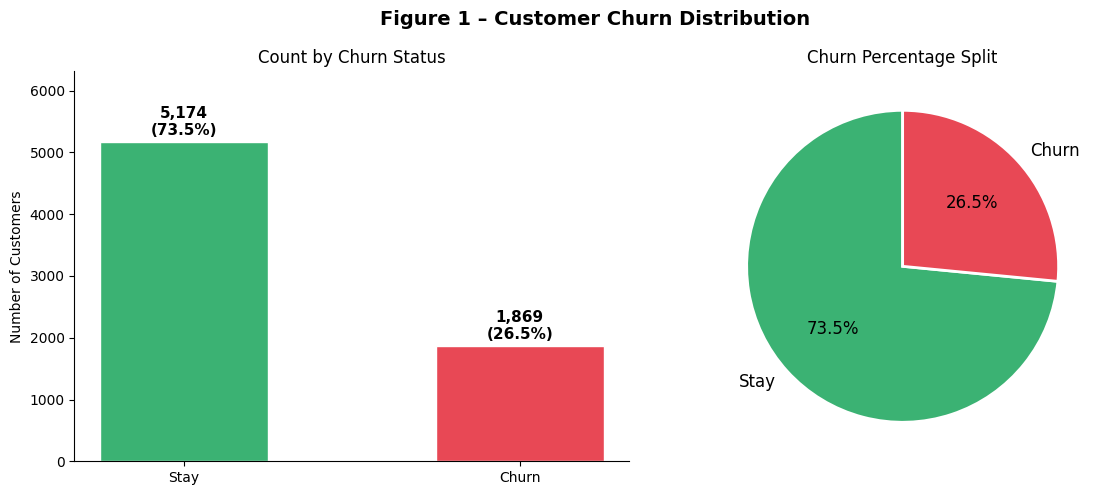

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 1 – Customer Churn Distribution', fontsize=14, fontweight='bold')
vals  = [(churn_arr==0).sum(), churn_arr.sum()]
lbls  = ['Stay', 'Churn']
clrs  = [COLORS['green'], COLORS['accent']]
bars  = axes[0].bar(lbls, vals, color=clrs, width=0.5, edgecolor='white')
for b, v in zip(bars, vals):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+60,
                 f'{v:,}\n({v/len(churn_arr)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Customers'); axes[0].set_title('Count by Churn Status')
axes[0].set_ylim(0, max(vals)*1.22)
axes[1].pie(vals, labels=lbls, colors=clrs, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2},
            textprops={'fontsize':12})
axes[1].set_title('Churn Percentage Split')
plt.tight_layout(); plt.show()

### Figure 2 – Tenure & Monthly Charges Distribution

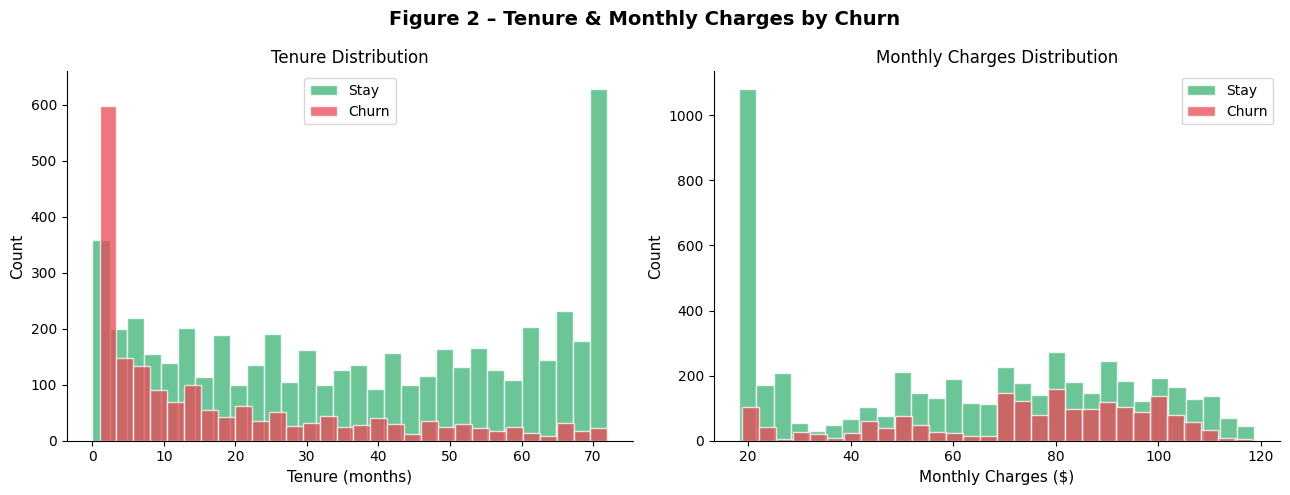

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2 – Tenure & Monthly Charges by Churn',
             fontsize=14, fontweight='bold')
for ax, data, xlabel, title in [
    (axes[0], tenure,  'Tenure (months)',     'Tenure Distribution'),
    (axes[1], monthly, 'Monthly Charges ($)',  'Monthly Charges Distribution')]:
    ax.hist(data[churn_arr==0], bins=30, alpha=0.75,
            color=COLORS['green'],  label='Stay',  edgecolor='white')
    ax.hist(data[churn_arr==1], bins=30, alpha=0.75,
            color=COLORS['accent'], label='Churn', edgecolor='white')
    ax.set_xlabel(xlabel, fontsize=11); ax.set_ylabel('Count', fontsize=11)
    ax.set_title(title); ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

### Figure 3 – Churn Rate by Contract & Internet Service

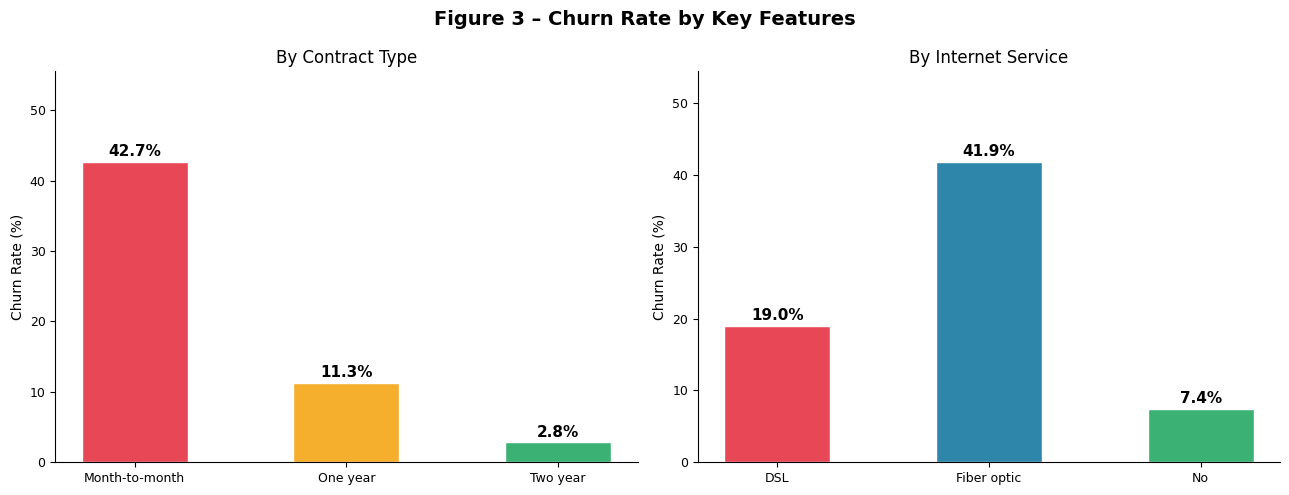

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 3 – Churn Rate by Key Features', fontsize=14, fontweight='bold')
cr1 = pd.DataFrame({'Contract':contract,'Churn':churn_arr}).groupby('Contract')['Churn'].mean()*100
cr1.sort_values(ascending=False)
cr2 = pd.DataFrame({'Internet':internet,'Churn':churn_arr}).groupby('Internet')['Churn'].mean()*100
cr2.sort_values(ascending=False)
configs = [
    (axes[0], cr1, [COLORS['accent'],COLORS['yellow'],COLORS['green']], 'By Contract Type'),
    (axes[1], cr2, [COLORS['accent'],COLORS['main'],  COLORS['green']], 'By Internet Service')
]
for ax, cr, pal, ttl in configs:
    bars = ax.bar(cr.index, cr.values, color=pal[:len(cr)], width=0.5, edgecolor='white')
    for b,v in zip(bars, cr.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.8,
                f'{v:.1f}%', ha='center', fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)'); ax.set_title(ttl)
    ax.set_ylim(0, cr.max()*1.3); ax.tick_params(labelsize=9)
plt.tight_layout(); plt.show()

### Figure 4 – Tenure vs Monthly Charges Scatter Plot

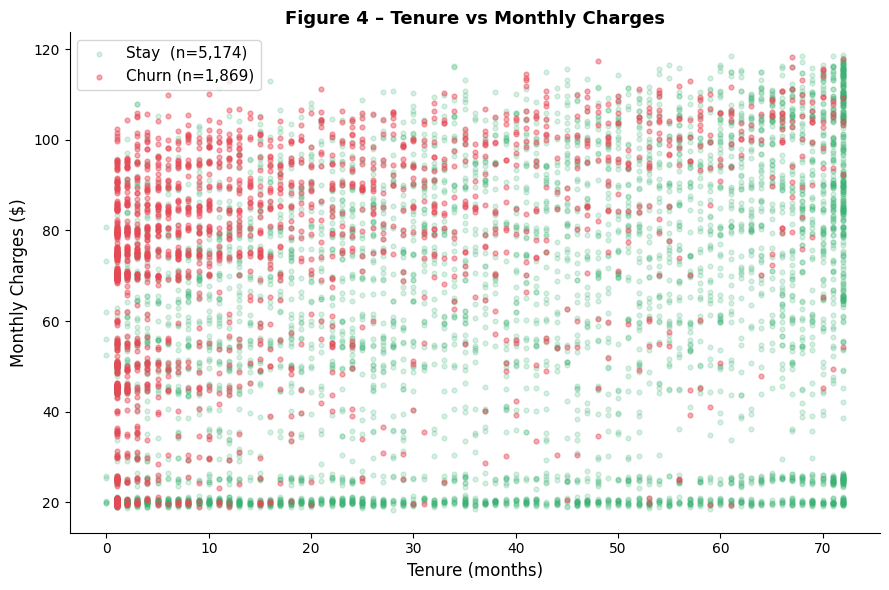

In [39]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(tenure[churn_arr==0], monthly[churn_arr==0],alpha=0.2, s=12, color=COLORS['green'],  label='Stay  (n=5,174)')
ax.scatter(tenure[churn_arr==1], monthly[churn_arr==1],alpha=0.45, s=12, color=COLORS['accent'], label='Churn (n=1,869)')
ax.set_xlabel('Tenure (months)', fontsize=12)
ax.set_ylabel('Monthly Charges ($)', fontsize=12)
ax.set_title('Figure 4 – Tenure vs Monthly Charges',fontsize=13, fontweight='bold')
ax.legend(fontsize=11); plt.tight_layout(); plt.show()

## 6. Train / Test Split & Feature Scaling

In [40]:
X = df_encoded.drop('Churn', axis=1).values.astype('float64')
y = df_encoded['Churn'].values
X = SimpleImputer(strategy='median').fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
sm = SMOTE(random_state=42)
X_train_sc, y_train = sm.fit_resample(X_train_sc, y_train)
print(f'Training set  : {X_train_sc.shape[0]:,} samples (80%)')
print(f'Test set      : {X_test_sc.shape[0]:,}  samples (20%)')
print(f'Input features: {X_train_sc.shape[1]}')
print(f'Train churn   : {y_train.sum():,} ({y_train.mean()*100:.1f}%)')
print(f'Test  churn   : {y_test.sum():,}  ({y_test.mean()*100:.1f}%)')

Training set  : 8,278 samples (80%)
Test set      : 1,409  samples (20%)
Input features: 32
Train churn   : 4,139 (50.0%)
Test  churn   : 374  (26.5%)


## 7. ANN Model — Architecture & Training

**Network:** Input → Dense(128, ReLU) → Dense(64, ReLU) → Dense(32, ReLU) → Dense(1, Sigmoid)

In [41]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision')
    ]
)
history = model.fit(
    X_train_sc, y_train,
    validation_split=0.15,
    epochs=200,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)



Epoch 1/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6991 - loss: 0.5848 - precision: 0.6523 - recall: 0.5765 - val_accuracy: 0.7464 - val_loss: 0.5618 - val_precision: 1.0000 - val_recall: 0.7464 - learning_rate: 3.0000e-04
Epoch 2/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7429 - loss: 0.5284 - precision: 0.6939 - recall: 0.6721 - val_accuracy: 0.7705 - val_loss: 0.5007 - val_precision: 1.0000 - val_recall: 0.7705 - learning_rate: 3.0000e-04
Epoch 3/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7523 - loss: 0.5083 - precision: 0.7065 - recall: 0.6814 - val_accuracy: 0.7842 - val_loss: 0.4876 - val_precision: 1.0000 - val_recall: 0.7842 - learning_rate: 3.0000e-04
Epoch 4/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7575 - loss: 0.5003 - precision: 0.7083 - recall: 0.6990 - val_accuracy: 0.7955 - val_loss: 0.4771 - val_precision: 1.0000 - val_recall: 0.7955 - learning_rate: 3.0000e-04
Epoch 5/200
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 

### Figure 5 – Training Loss Curve

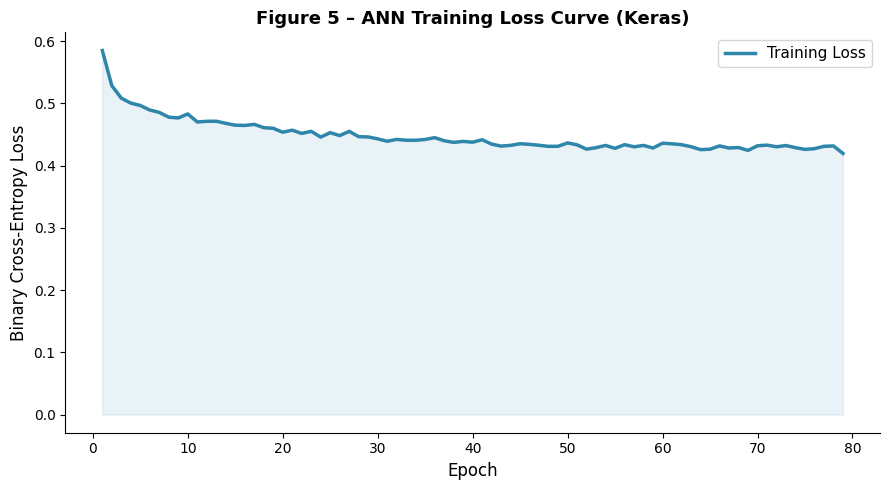

In [42]:
fig, ax = plt.subplots(figsize=(9, 5))
epochs = range(1, len(history.history['loss']) + 1)
ax.plot(epochs, history.history['loss'],color=COLORS['main'], lw=2.5, label='Training Loss')
ax.fill_between(epochs, history.history['loss'],alpha=0.1, color=COLORS['main'])
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Binary Cross-Entropy Loss', fontsize=12)
ax.set_title('Figure 5 – ANN Training Loss Curve (Keras)',fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 8. Model Evaluation

In [47]:
y_prob = model.predict(X_test_sc).ravel()

best_t, best_score = 0, 0

for t in np.arange(0.3, 0.8, 0.001):
    y_pred_temp = (y_prob >= t).astype(int)
    score = f1_score(y_test, y_pred_temp)

    if score > best_score:
        best_score = score
        best_t = t
print("Best Threshold (Accuracy):", best_t)
y_pred = (y_prob >= best_t).astype(int)
print(classification_report(y_test, y_pred))



45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Best Threshold (Accuracy): 0.5120000000000002
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409



### Figure 6 – Confusion Matrix

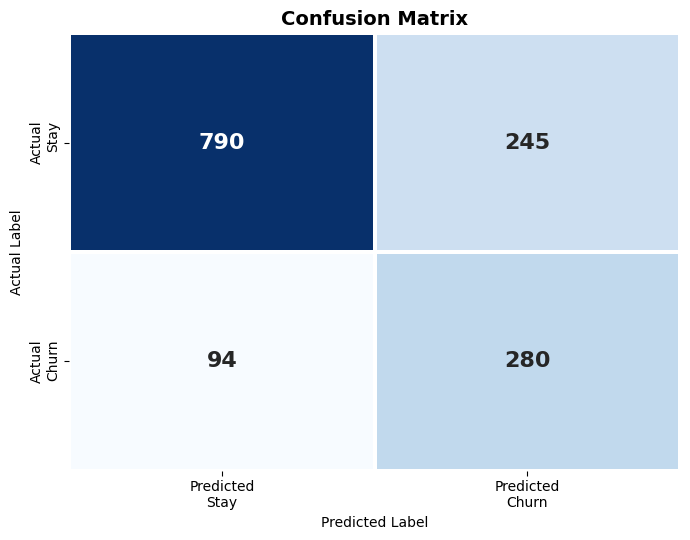

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
cm_val = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(
    cm_val,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted\nStay', 'Predicted\nChurn'],
    yticklabels=['Actual\nStay', 'Actual\nChurn'],
    linewidths=1.5,
    linecolor='white',
    cbar=False,
    annot_kws={'size':16, 'weight':'bold'},
    ax=ax
)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')

plt.tight_layout()
plt.show()


### Figure 7 – ROC-AUC Curve

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


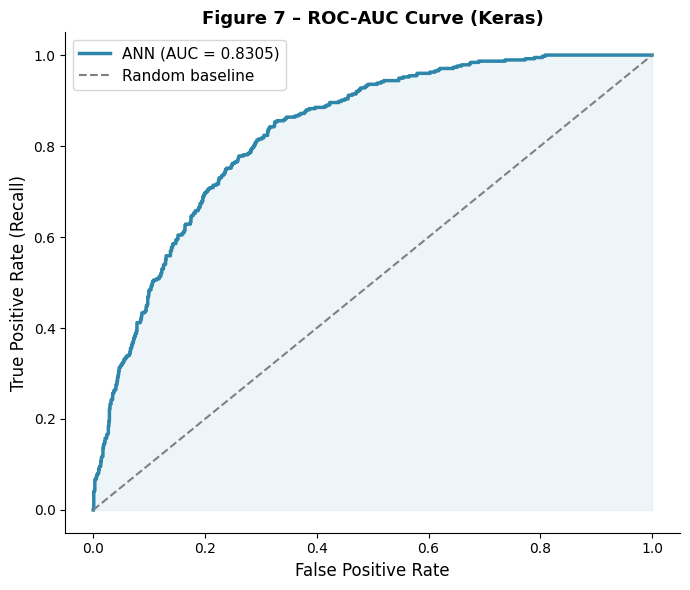

In [45]:
from sklearn.metrics import roc_curve, auc
y_pred_proba = model.predict(X_test_sc).flatten()
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_val = auc(fpr, tpr)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=COLORS['main'], lw=2.5,label=f'ANN (AUC = {roc_val:.4f})')
ax.plot([0,1],[0,1], color='gray', ls='--', lw=1.5,label='Random baseline')
ax.fill_between(fpr, tpr, alpha=0.08, color=COLORS['main'])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('Figure 7 – ROC-AUC Curve (Keras)',fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()